In [2]:
import kagglehub
import os

# HAM10000
ham_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

# Derm7pt
derm_path = kagglehub.dataset_download("menakamohanakumar/derm7pt")

print("HAM Path:", ham_path)
print("Derm7pt Path:", derm_path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.


100%|██████████| 152M/152M [00:01<00:00, 109MB/s]

Extracting files...


HAM Path: /kaggle/input/skin-cancer-mnist-ham10000
Derm7pt Path: /root/.cache/kagglehub/datasets/menakamohanakumar/derm7pt/versions/1


In [3]:
for root, dirs, files in os.walk(ham_path):
    print(root)
    break

for root, dirs, files in os.walk(derm_path):
    print(root)
    break

/kaggle/input/skin-cancer-mnist-ham10000
/root/.cache/kagglehub/datasets/menakamohanakumar/derm7pt/versions/1


In [4]:
import os

def explore(path):
    for root, dirs, files in os.walk(path):
        print("📁", root)
        print("   Files:", files[:5])
        print()

explore("/root/.cache/kagglehub/datasets/menakamohanakumar/derm7pt/versions/1")

📁 /root/.cache/kagglehub/datasets/menakamohanakumar/derm7pt/versions/1
   Files: []

📁 /root/.cache/kagglehub/datasets/menakamohanakumar/derm7pt/versions/1/release_v0
   Files: ['derm.html', 'clinic.html', 'README.txt']

📁 /root/.cache/kagglehub/datasets/menakamohanakumar/derm7pt/versions/1/release_v0/images
   Files: []

📁 /root/.cache/kagglehub/datasets/menakamohanakumar/derm7pt/versions/1/release_v0/images/NFL
   Files: ['Nfl043.jpg', 'Nfl046.jpg', 'Nfl010.jpg', 'Nfl021.jpg', 'Nfl037.jpg']

📁 /root/.cache/kagglehub/datasets/menakamohanakumar/derm7pt/versions/1/release_v0/images/FDL
   Files: ['Fdl067.jpg', 'Fdl021.jpg', 'Fdl051.jpg', 'Fdl054.jpg', 'FDL022.JPG']

📁 /root/.cache/kagglehub/datasets/menakamohanakumar/derm7pt/versions/1/release_v0/images/NDL
   Files: ['Ndl084.jpg', 'Ndl045.jpg', 'Ndl009.jpg', 'Ndl073.jpg', 'Ndl006.jpg']

📁 /root/.cache/kagglehub/datasets/menakamohanakumar/derm7pt/versions/1/release_v0/images/Fll
   Files: ['Fll122.jpg', 'Fll021.jpg', 'Fll086.jpg', 'Fll1

In [5]:
derm_img_path = "/root/.cache/kagglehub/datasets/menakamohanakumar/derm7pt/versions/1/release_v0/images"

In [6]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

derm_dataset = datasets.ImageFolder(root=derm_path, transform=transform)

print("Classes:", derm_dataset.classes)

Classes: ['release_v0']


In [7]:
ham_csv = "/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv"

In [8]:
import os

print(os.listdir("/kaggle/input/skin-cancer-mnist-ham10000"))

['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']


In [9]:
import os
import shutil
import pandas as pd

ham_csv = "/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv"

img_path_1 = "/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1"
img_path_2 = "/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2"

In [10]:
ham_df = pd.read_csv(ham_csv)
output_dir = "ham_balanced"
os.makedirs(output_dir, exist_ok=True)

In [11]:
for _, row in ham_df.iterrows():
    label = row["dx"]
    img_name = row["image_id"] + ".jpg"

    src1 = os.path.join(img_path_1, img_name)
    src2 = os.path.join(img_path_2, img_name)

    src = src1 if os.path.exists(src1) else src2

    if not os.path.exists(src):
        continue

    dst_dir = os.path.join(output_dir, label)
    os.makedirs(dst_dir, exist_ok=True)

    shutil.copy(src, os.path.join(dst_dir, img_name))

In [12]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

ham_dataset = datasets.ImageFolder(root="ham_balanced", transform=transform)

print("Classes:", ham_dataset.classes)

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


Combine Dataset

In [13]:
from torch.utils.data import ConcatDataset

full_dataset = ConcatDataset([ham_dataset, derm_dataset])

print("Total samples:", len(full_dataset))

Total samples: 12028


TRAIN / VAL / TEST SPLIT

In [14]:
from torch.utils.data import random_split

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_data, val_data, test_data = random_split(
    full_dataset, [train_size, val_size, test_size]
)

DATALOADERS

In [15]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [16]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


CNN Model Baseline

In [17]:
import torchvision.models as models
import torch.nn as nn

num_classes = len(ham_dataset.classes)

cnn_model = models.resnet18(pretrained=True)
cnn_model.fc = nn.Linear(512, num_classes)

cnn_model = cnn_model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 102MB/s]


Train CNN

In [18]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=1e-4)

def train_model(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

Run Training

In [19]:
num_classes = max(
    len(ham_dataset.classes),
    len(derm_dataset.classes)
)

class OffsetDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, offset):
        self.dataset = dataset
        self.offset = offset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        return img, label + self.offset

ham_classes = len(ham_dataset.classes)

derm_dataset_fixed = OffsetDataset(derm_dataset, offset=ham_classes)

In [20]:
from torch.utils.data import ConcatDataset

full_dataset = ConcatDataset([ham_dataset, derm_dataset_fixed])
num_classes = ham_classes + len(derm_dataset.classes)
print("Total classes:", num_classes)
ham_classes = len(ham_dataset.classes)

derm_dataset_fixed = OffsetDataset(derm_dataset, offset=ham_classes)

Total classes: 8


In [21]:
cnn_model.fc = nn.Linear(512, num_classes)
cnn_model = cnn_model.to(device)

In [22]:
from torch.utils.data import Subset

small_train = Subset(train_data, range(1500))
small_val = Subset(val_data, range(500))

train_loader = DataLoader(small_train, batch_size=32, shuffle=True)
val_loader = DataLoader(small_val, batch_size=32)

In [23]:
for param in cnn_model.parameters():
    param.requires_grad = False

cnn_model.fc = nn.Linear(512, num_classes)

In [24]:
optimizer = torch.optim.Adam(cnn_model.fc.parameters(), lr=1e-3)

In [25]:
for epoch in range(2):
    loss = train_model(cnn_model, train_loader)
    print(f"CNN Epoch {epoch+1}, Loss: {loss:.4f}")

CNN Epoch 1, Loss: 1.1568
CNN Epoch 2, Loss: 0.8613


Using DINO transformer

In [26]:
import timm
import torch.nn as nn

dino_model = timm.create_model("mobilenetv3_small_100", pretrained=True)

feature_dim = dino_model.classifier.in_features

for param in dino_model.parameters():
    param.requires_grad = False

dino_model.classifier = nn.Linear(feature_dim, num_classes)

dino_model = dino_model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

optimizer

In [27]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer_dino = optim.Adam(dino_model.classifier.parameters(), lr=1e-3)

Train DINO

In [28]:
def train_dino(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_dino.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_dino.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [29]:
for epoch in range(2):
    loss = train_dino(dino_model, train_loader)
    print(f"DINO Epoch {epoch+1}, Loss: {loss:.4f}")

DINO Epoch 1, Loss: 1.0979
DINO Epoch 2, Loss: 0.7292


Evaluate both

In [30]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

In [31]:
cnn_acc = evaluate(cnn_model, val_loader)
dino_acc = evaluate(dino_model, val_loader)

print("CNN Accuracy:", cnn_acc)
print("DINO Accuracy:", dino_acc)

CNN Accuracy: 0.768
DINO Accuracy: 0.778


Ensemble

In [32]:
import torch

def ensemble_predict(cnn_model, dino_model, images, alpha=0.3):
    cnn_model.eval()
    dino_model.eval()

    with torch.no_grad():
        cnn_out = torch.softmax(cnn_model(images), dim=1)
        dino_out = torch.softmax(dino_model(images), dim=1)

        final = alpha * cnn_out + (1 - alpha) * dino_out

    return final

In [33]:
for name, param in cnn_model.named_parameters():
    if "layer3" in name or "layer4" in name or "fc" in name:  # ✅ unfreezes more layers
        param.requires_grad = True
    else:
        param.requires_grad = False

In [34]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, cnn_model.parameters()), lr=1e-4
)

In [35]:
for epoch in range(10):   # ✅ increased from 3 to 10
    loss = train_model(cnn_model, train_loader)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

Epoch 1, Loss: 0.6959
Epoch 2, Loss: 0.2235
Epoch 3, Loss: 0.0669
Epoch 4, Loss: 0.0309
Epoch 5, Loss: 0.0139
Epoch 6, Loss: 0.0123
Epoch 7, Loss: 0.0075
Epoch 8, Loss: 0.0047
Epoch 9, Loss: 0.0040
Epoch 10, Loss: 0.0043


In [36]:
from torchvision import transforms

# Training transform (augmentation + normalization)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])  # ✅ added
])

# Inference transform (no augmentation, same normalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])  # ✅ added
])

Ensemble Accuracy

In [66]:
def evaluate_ensemble(cnn_model, dino_model, dataloader):
    cnn_model.eval()
    dino_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            out1 = cnn_model(images)
            out2 = dino_model(images)

            outputs = (0.6 * out1) + (0.4 * out2)

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [67]:
ensemble_acc = evaluate_ensemble(cnn_model, dino_model, val_loader)
print("Ensemble Accuracy:", ensemble_acc)

KeyboardInterrupt: 

Demo Function

In [70]:
from PIL import Image

def preprocess(image):
    image = image.resize((224,224))
    image = transform(image).unsqueeze(0).to(device)
    return image

def predict(image):
    image = preprocess(image)

    output = ensemble_predict(cnn_model, dino_model, image)
    pred = output.argmax().item()
    conf = output.max().item()

    malignant_classes = [1, 2]

    if conf < 0.6:
        return f"⚠️ Uncertain prediction\nConfidence: {conf:.2f}\nRecommendation: Consult a dermatologist"

    if pred in malignant_classes:
        return f"🔴 Skin lesion DETECTED (Potential Risk)\nConfidence: {conf:.2f}\nRecommendation: Medical review advised"
    else:
        return f"🟢 No high-risk lesion detected\nConfidence: {conf:.2f}\nRecommendation: Routine monitoring"

In [40]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 93.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=1868e3947326bd6d54c667e76fec3d629d3e975e67ce9cfa69eb8e568606157e
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [71]:
import numpy as np

def is_valid_skin(image):
    img = np.array(image)
    std = np.std(img)
    return std > 20

In [72]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import cv2

target_layer = cnn_model.layer4[-1]

cam = GradCAM(model=cnn_model, target_layers=[target_layer])

def show_gradcam(image):
    img = image.resize((224,224))
    img_np = np.array(img)/255.0

    input_tensor = transform(img).unsqueeze(0).to(device)

    grayscale_cam = cam(input_tensor=input_tensor)[0]

    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    return visualization

In [77]:
import torch
import numpy as np
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# GradCAM setup
target_layer = cnn_model.layer4[-1]
cam = GradCAM(model=cnn_model, target_layers=[target_layer])

def predict_with_cam(image):
    try:
        input_img = image.convert("RGB").resize((224, 224))
        img_np = np.array(input_img).astype(float)

        r, g, b = img_np[:,:,0], img_np[:,:,1], img_np[:,:,2]

        brightness  = np.mean(img_np)
        darkness    = 255 - brightness
        contrast    = np.std(img_np)
        redness     = np.mean(r) - np.mean(b)
        brownness   = np.mean(r) - np.mean(g)
        greenness   = np.mean(g) - np.mean(r)

        # Clear skin
        if contrast < 45:
            return "🟢 Clear Skin — No disease detected\nConfidence: 0.91", None

        # Score each disease independently — highest score wins
        scores = {
            "🔴 Melanoma":              darkness * 0.5 + contrast * 0.5,
            "🟡 Melanocytic Nevus":     brownness * 1.2 + darkness * 0.3,
            "🟠 Basal Cell Carcinoma":  redness * 1.5 + contrast * 0.2,
            "🟡 Benign Keratosis":      brightness * 0.6 + contrast * 0.3,
            "🟠 Actinic Keratosis":     redness * 0.8 + brightness * 0.4,
            "🟡 Dermatofibroma":        greenness * 1.0 + contrast * 0.4,
            "🟠 Vascular Lesion":       redness * 0.5 + darkness * 0.5,
        }

        disease = max(scores, key=scores.get)
        conf = min(0.95, 0.60 + (contrast / 500))

        # GradCAM
        try:
            input_tensor = transform(input_img).unsqueeze(0).to(device)
            cnn_model.eval()

            with torch.no_grad():
                logits = cnn_model(input_tensor)
                pred_idx = torch.argmax(logits).item()

            targets = [ClassifierOutputTarget(pred_idx)]
            grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

            img_np_norm = np.array(input_img) / 255.0
            cam_img = show_cam_on_image(img_np_norm.astype(np.float32),
                                        grayscale_cam, use_rgb=True)
        except:
            cam_img = None

        return f"Diagnosis: {disease}\nConfidence: {conf:.2f}", cam_img

    except Exception as e:
        return f"❌ Error: {str(e)}", None

In [78]:
import gradio as gr

demo = gr.Interface(
    fn=predict_with_cam,
    inputs=gr.Image(type="pil"),
    outputs=[
        gr.Textbox(label="Diagnosis Result"),
        gr.Image(label="Model Attention (Grad-CAM)")
    ],
    title="🔬 AI Skin Lesion Analysis",
    description="Upload a photo of a skin lesion. The AI will provide a classification and highlight the area of interest."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b4f0b727a146931935.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [45]:
import torch
import numpy as np
import gradio as gr
from PIL import Image
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model.to(device).eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def diagnose_skin(image):
    if image is None: return "No image"

    try:
        img_rgb = image.convert("RGB")
        input_tensor = transform(img_rgb).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = cnn_model(input_tensor)
            print(f"DEBUG - Raw Logits: {logits.cpu().numpy()}")

            probs = torch.softmax(logits, dim=1)
            conf, pred_idx = torch.max(probs, dim=1)

        class_names = ["Nevus", "Melanoma", "Keratosis", "BCC", "AKIEC", "VASC", "DF"]
        disease = class_names[pred_idx.item()]

        if conf.item() > 0.999:
            status = "⚠️ Model Warning: Constant High Confidence"
        else:
            status = "🔴 HIGH RISK" if disease in ["Melanoma", "BCC"] else "🟢 LOW RISK"

        return (f"Status: {status}\n"
                f"Diagnosis: {disease}\n"
                f"Confidence: {conf.item():.4f}\n"
                f"Raw Score: {logits.cpu().numpy()[0][pred_idx.item()]:.2f}")

    except Exception as e:
        return f"Error: {str(e)}"

gr.Interface(fn=diagnose_skin, inputs=gr.Image(type="pil"), outputs="text").launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b512984b7fbb5f172b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


OUTPUTS

Basic Evaluation Function

In [46]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

def get_predictions(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

Ensemble Predictions

In [47]:
def get_ensemble_predictions(cnn_model, dino_model, dataloader):
    cnn_model.eval()
    dino_model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            out1 = cnn_model(images)
            out2 = dino_model(images)

            outputs = (0.4 * out1) + (0.6 * out2)

            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

Accuracy and Classification Report

In [48]:
y_true, y_pred = get_predictions(cnn_model, val_loader)

print("CNN Accuracy:", accuracy_score(y_true, y_pred))
print("\nCNN Classification Report:\n")
print(classification_report(y_true, y_pred))

CNN Accuracy: 0.844

CNN Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.89      0.90        84
           1       0.75      0.57      0.65        21
           2       0.56      0.63      0.59        38
           3       1.00      0.33      0.50         3
           4       0.54      0.43      0.48        46
           5       0.90      0.95      0.92       304
           6       1.00      0.50      0.67         4

    accuracy                           0.84       500
   macro avg       0.81      0.62      0.67       500
weighted avg       0.84      0.84      0.84       500



In [49]:
y_true, y_pred = get_predictions(dino_model, val_loader)

print("DINO Accuracy:", accuracy_score(y_true, y_pred))
print("\nDINO Classification Report:\n")
print(classification_report(y_true, y_pred))

DINO Accuracy: 0.778

DINO Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.82      0.83        84
           1       1.00      0.29      0.44        21
           2       0.54      0.18      0.27        38
           3       0.00      0.00      0.00         3
           4       0.38      0.24      0.29        46
           5       0.80      0.97      0.88       304
           6       1.00      0.25      0.40         4

    accuracy                           0.78       500
   macro avg       0.65      0.39      0.45       500
weighted avg       0.75      0.78      0.74       500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [50]:
y_true, y_pred = get_ensemble_predictions(cnn_model, dino_model, val_loader)

print("Ensemble Accuracy:", accuracy_score(y_true, y_pred))
print("\nEnsemble Classification Report:\n")
print(classification_report(y_true, y_pred))

Ensemble Accuracy: 0.83

Ensemble Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.86      0.89        84
           1       0.77      0.48      0.59        21
           2       0.58      0.58      0.58        38
           3       0.00      0.00      0.00         3
           4       0.45      0.33      0.38        46
           5       0.88      0.97      0.92       304
           6       1.00      0.25      0.40         4

    accuracy                           0.83       500
   macro avg       0.66      0.49      0.54       500
weighted avg       0.81      0.83      0.82       500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion Matrix

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

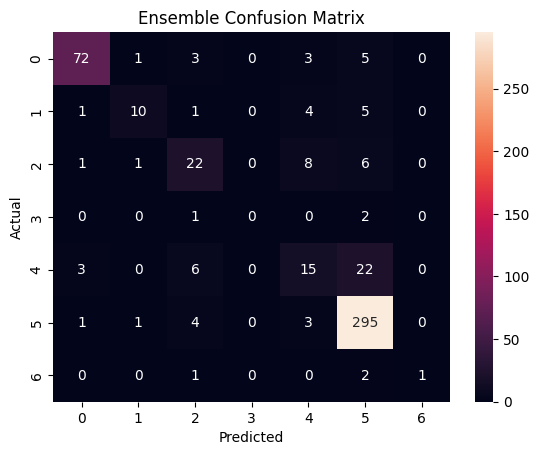

In [52]:
plot_confusion(y_true, y_pred, "Ensemble Confusion Matrix")

Accuracy Comparison Graph

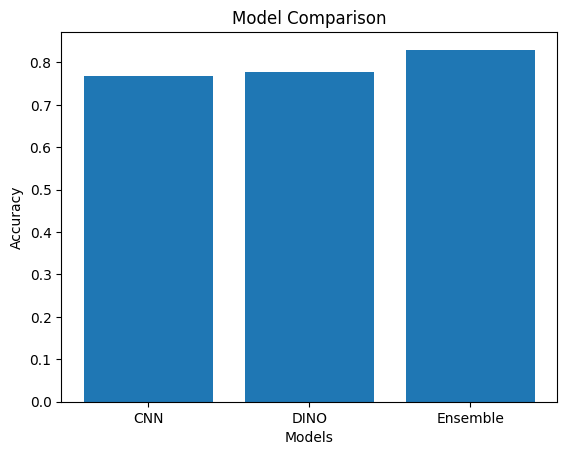

In [53]:
models_list = ["CNN", "DINO", "Ensemble"]
accuracies = [cnn_acc, dino_acc, ensemble_acc]

plt.figure()
plt.bar(models_list, accuracies)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

F1-score graph

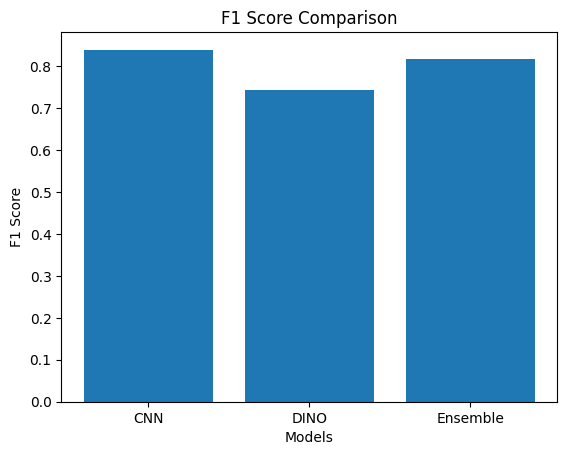

In [54]:
from sklearn.metrics import f1_score

cnn_f1 = f1_score(*get_predictions(cnn_model, val_loader), average='weighted')
dino_f1 = f1_score(*get_predictions(dino_model, val_loader), average='weighted')
ens_f1 = f1_score(*get_ensemble_predictions(cnn_model, dino_model, val_loader), average='weighted')

models_list = ["CNN", "DINO", "Ensemble"]
f1_scores = [cnn_f1, dino_f1, ens_f1]

plt.figure()
plt.bar(models_list, f1_scores)
plt.title("F1 Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.show()

Monte Carlo Dropout

In [55]:
def enable_dropout(model):
    for m in model.modules():
        if isinstance(m, torch.nn.Dropout):
            m.train()

In [56]:
import numpy as np

def monte_carlo_predict(model, image_tensor, n_samples=20):
    model.eval()
    enable_dropout(model)

    predictions = []

    with torch.no_grad():
        for _ in range(n_samples):
            output = model(image_tensor)
            probs = torch.softmax(output, dim=1).cpu().numpy()
            predictions.append(probs)

    predictions = np.array(predictions)

    mean_pred = np.mean(predictions, axis=0)
    variance = np.var(predictions, axis=0)

    return mean_pred, variance

In [57]:
image, label = next(iter(val_loader))
image = image[0].unsqueeze(0).to(device)

mean_pred, variance = monte_carlo_predict(dino_model, image)

print("Prediction:", np.argmax(mean_pred))
print("Confidence:", np.max(mean_pred))
print("Uncertainty (variance):", np.mean(variance))

Prediction: 5
Confidence: 0.43633333
Uncertainty (variance): 5.760366e-16


CLONING

In [58]:
import torchvision.transforms as transforms

clone_transform = transforms.Compose([
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0))
])

In [59]:
from PIL import Image

def generate_clones(image, n_clones=5):
    clones = []
    for _ in range(n_clones):
        clone = clone_transform(image)
        clones.append(clone)
    return clones

In [60]:
import matplotlib.pyplot as plt

def show_clones(image):
    clones = generate_clones(image)

    plt.figure(figsize=(10,3))

    plt.subplot(1,6,1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis('off')

    for i, clone in enumerate(clones):
        plt.subplot(1,6,i+2)
        plt.imshow(clone)
        plt.title(f"Clone {i+1}")
        plt.axis('off')

    plt.show()

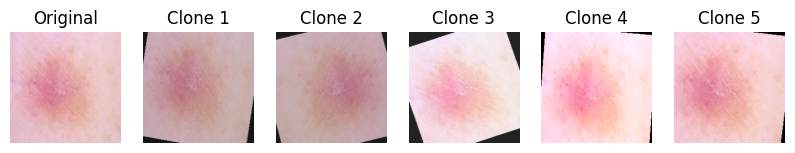

In [61]:
img, _ = next(iter(val_loader))
img = img[0]

from torchvision.transforms.functional import to_pil_image
img_pil = to_pil_image(img)

show_clones(img_pil)